In [1]:
import pandas as pd

In [2]:
dados = pd.read_csv(r'Dados\Preços_de_casas.csv')


In [3]:
dados.info()


<class 'pandas.DataFrame'>
RangeIndex: 1438 entries, 0 to 1437
Data columns (total 8 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Id                              1438 non-null   int64  
 1   area_primeiro_andar             1438 non-null   float64
 2   existe_segundo_andar            1438 non-null   int64  
 3   area_segundo_andar              1438 non-null   float64
 4   quantidade_banheiros            1438 non-null   int64  
 5   capacidade_carros_garagem       1438 non-null   int64  
 6   qualidade_da_cozinha_Excelente  1438 non-null   int64  
 7   preco_de_venda                  1438 non-null   float64
dtypes: float64(3), int64(5)
memory usage: 90.0 KB


In [4]:
dados = dados.drop(columns=["Id"])

In [5]:
corr = dados.corr()

In [6]:
corr['preco_de_venda']

area_primeiro_andar               0.616557
existe_segundo_andar              0.138541
area_segundo_andar                0.305311
quantidade_banheiros              0.563132
capacidade_carros_garagem         0.640214
qualidade_da_cozinha_Excelente    0.496223
preco_de_venda                    1.000000
Name: preco_de_venda, dtype: float64

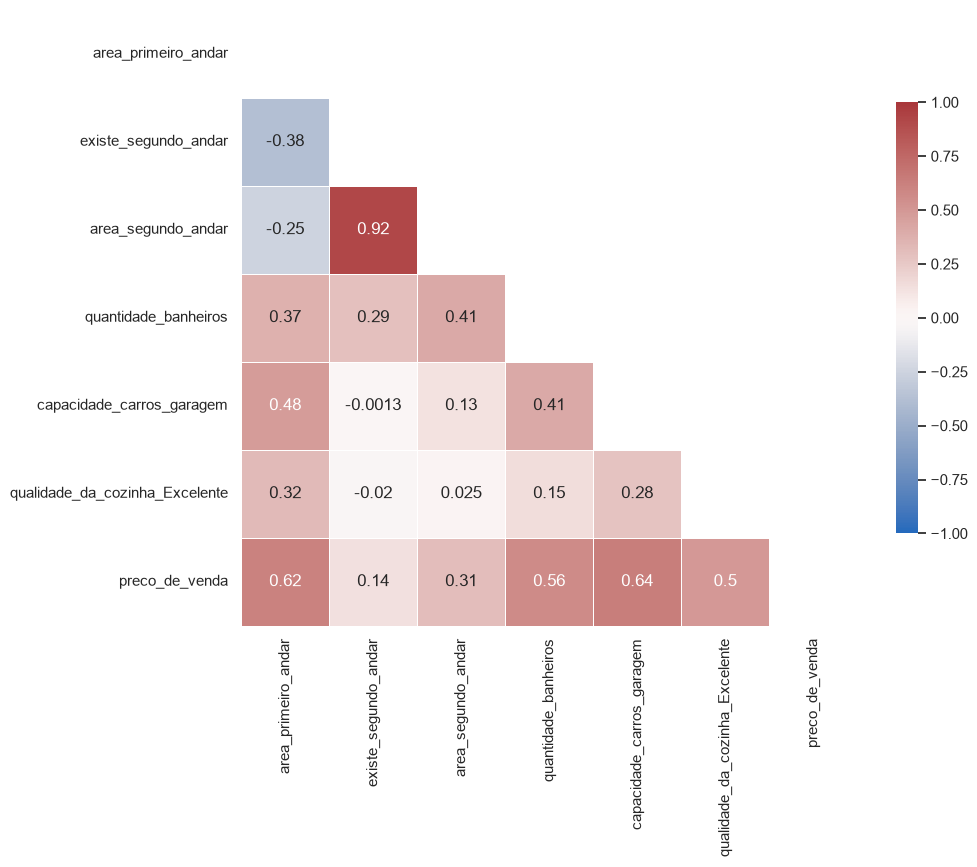

In [7]:
# Importa as bibliotecas necessárias para análise e visualização de dados
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configura o estilo dos gráficos do Seaborn para um visual mais limpo
sns.set_theme(style="white")

# 1. Calcula a matriz de correlação de todas as variáveis do DataFrame 'dados'
corr = dados.corr()

# 2. Cria uma máscara para o triângulo superior da matriz
# Como a matriz é simétrica, a parte de cima e a de baixo são iguais. 
# Usamos a máscara para esconder a metade superior e evitar redundância.
mask = np.triu(np.ones_like(corr, dtype=bool))

# 3. Configura o tamanho da figura (largura x altura em polegadas)
f, ax = plt.subplots(figsize=(10, 8))

# 4. Define a paleta de cores divergente (azul para negativo, vermelho para positivo, branco para neutro)
# O mapa de cores 'coolwarm' ou 'vlag' replica exatamente o tom do seu exercício
cmap = sns.color_palette("vlag", as_cmap=True)

# 5. Desenha o mapa de calor (heatmap) com os parâmetros específicos da imagem:
sns.heatmap(
    corr,                      # Os dados da nossa matriz de correlação
    mask=mask,                 # Aplica a máscara para ocultar o triângulo superior
    cmap=cmap,                 # Aplica a paleta de cores definida acima
    vmax=1.0,                  # Valor máximo da escala de cor (Correlação Perfeita Positiva)
    vmin=-1.0,                 # Valor mínimo da escala de cor (Correlação Perfeita Negativa)
    center=0,                  # Define o ponto neutro (zero) no meio da escala
    annot=True,                # Mostra os valores numéricos dentro dos quadrados
    fmt=".2g",                 # Formata os números para mostrar de forma limpa (ex: 0.32, -0.0026)
    square=True,               # Força cada célula a ser um quadrado perfeito
    linewidths=.5,             # Cria as linhas brancas divisórias entre os quadrados
    cbar_kws={"shrink": .7}    # Encolhe um pouco a barra lateral de cores para ajustar ao layout
)

# 6. Exibe o gráfico finalizado na tela
plt.show()


In [8]:
# Importando as visualizações
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

Text(0, 0.5, 'Preço de venda')

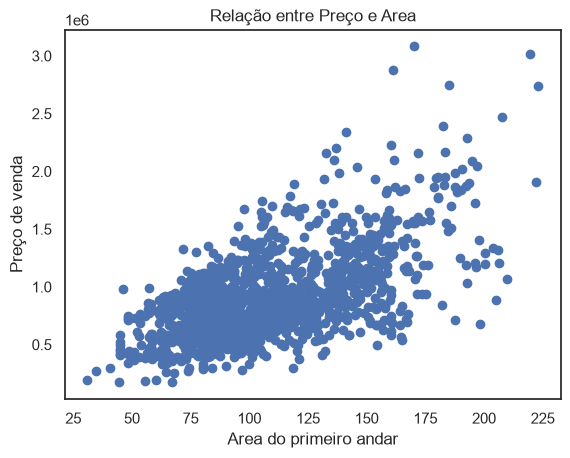

In [9]:
# Aparentemente, quanto maior a área do primeiro andar, maior o preço da casa.
# E se quisermos traçar uma linha que melhor representa esse comportamento?
plt.scatter(dados['area_primeiro_andar'], dados['preco_de_venda'])
plt.title("Relação entre Preço e Area")
plt.xlabel("Area do primeiro andar")
plt.ylabel("Preço de venda")

Text(0, 0.5, 'Preço de venda')

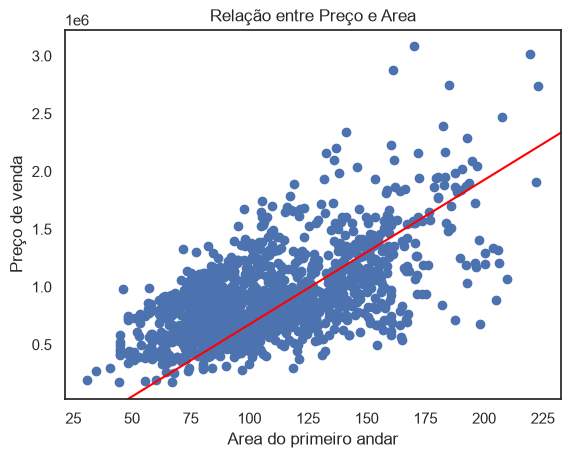

In [10]:
# Aparentemente, quanto maior a área do primeiro andar, maior o preço da casa.
# E se quisermos traçar uma linha que melhor representa esse comportamento?
plt.scatter(dados['area_primeiro_andar'], dados['preco_de_venda'])
plt.axline(xy1 = (66, 250000),xy2 = (190, 1800000), color = "red" )
plt.title("Relação entre Preço e Area")
plt.xlabel("Area do primeiro andar")
plt.ylabel("Preço de venda")

In [13]:
# Qual a reta que melhor se adequa a relação?

# Cria o gráfico de dispersão com a linha de regressão linear customizada na cor vermelha
# - dados: Nosso conjunto de dados (DataFrame)
# - x: Variável preditora no eixo X (Área do primeiro andar)
# - y: Variável resposta no eixo Y (Preço de venda do imóvel)
# - trendline='ols': Método dos Mínimos Quadrados para calcular a reta de tendência
# - trendline_color_override='red': Altera especificamente a cor da linha de tendência para vermelho
px.scatter(
    dados, 
    x='area_primeiro_andar', 
    y='preco_de_venda', 
    trendline='ols',
    trendline_color_override='red'
)
